In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
(x_train,y_train), (x_test,y_test) = fashion_mnist.load_data()
print("Training Images Shape", x_train.shape)
print("Training Labels Shape", y_train.shape)
print("Testing Images Shape", x_test.shape)
print("Testing Labels Shape", y_test.shape)

Training Images Shape (60000, 28, 28)
Training Labels Shape (60000,)
Testing Images Shape (10000, 28, 28)
Testing Labels Shape (10000,)


In [ ]:
class_names = ['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

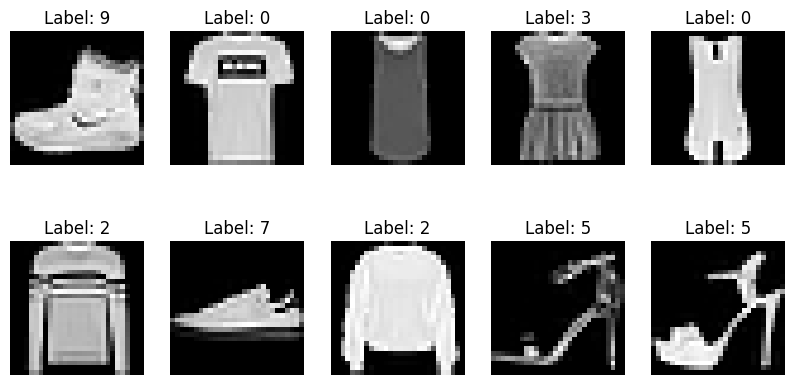

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [ ]:
x_train = x_train/255.0
x_test = x_test/255.0

In [ ]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [ ]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
model = Sequential()

# layer 1
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))     #First Convolution Layer
model.add(MaxPooling2D(pool_size=(2,2)))                                               #First Pooling Layer

#layer 2
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))                            #Second Convolution Layer
model.add(MaxPooling2D(pool_size=(2,2)))                                               #Second Pooling Layer

#Flatten Layer
model.add(Flatten())

#Fully Connected Layer
model.add(Dense(128, activation='relu'))

#Dropout Layer
model.add(Dropout(0.5))

#Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, batch_size=32, epochs=20, validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9286 - loss: 0.1911 - val_accuracy: 0.9142 - val_loss: 0.2555
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9308 - loss: 0.1853 - val_accuracy: 0.9168 - val_loss: 0.2383
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9329 - loss: 0.1771 - val_accuracy: 0.9145 - val_loss: 0.2466
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9357 - loss: 0.1675 - val_accuracy: 0.9137 - val_loss: 0.2571
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9397 - loss: 0.1595 - val_accuracy: 0.9142 - val_loss: 0.2646
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9418 - loss: 0.1547 - val_accuracy: 0.9145 - val_loss: 0.2659
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9416 - loss: 0.1494 - val_accuracy: 0.9153 - val_loss: 0.2717
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9445 - loss: 0.1436 - 

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Loss", test_loss)
print("Test Accuracy", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9135 - loss: 0.3503
Test Loss 0.350269079208374
Test Accuracy 0.9135000109672546


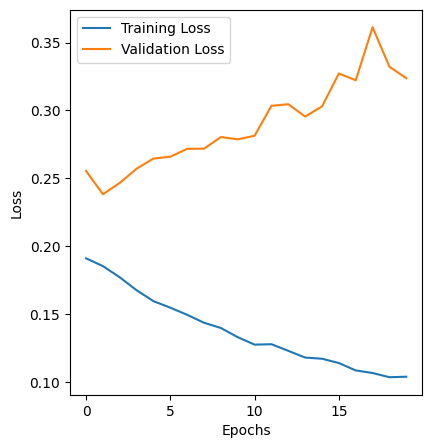

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

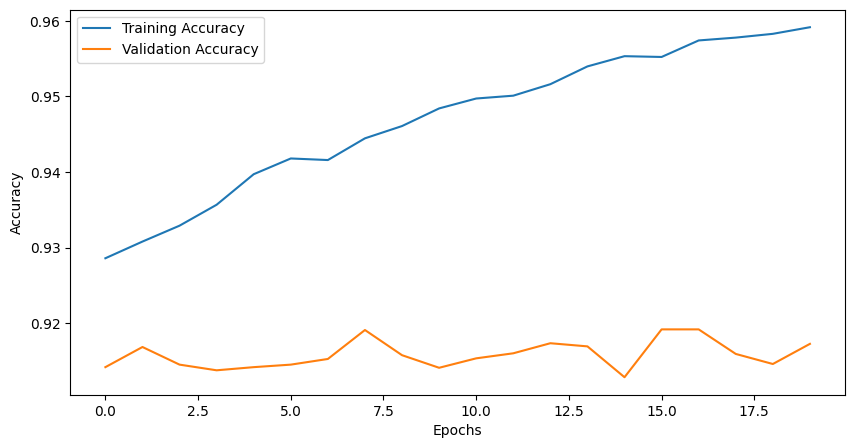

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


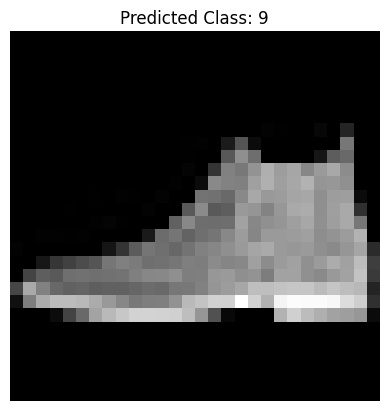

In [ ]:
sample = x_test[0]
prediction = model.predict(sample.reshape(1,28,28,1))
predicted_class = np.argmax(prediction)
plt.imshow(sample.reshape(28,28), cmap='gray')
plt.title(f"Predicted Class: {predicted_class}")
plt.axis('off')
plt.show()

Saving istockphoto-1054618448-612x612.jpg to istockphoto-1054618448-612x612 (1).jpg


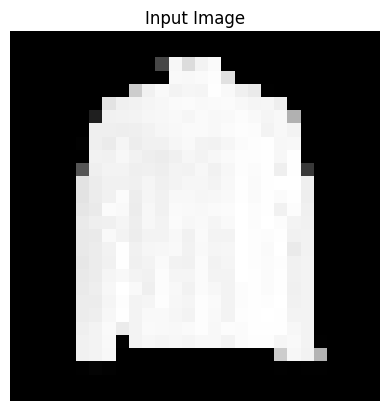

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Fashion Item: T-shirt/Top
Confidence Score 100.0 %


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import cv2
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28,28))

#Normalize
img = img.astype("float32")/255.0

#Invert colors
img = 255-img

#Display
plt.imshow(img, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.show()

#Reshape for CNN
img = img.reshape(1,28,28,1)

#Predict
prediction = model.predict(img)
predicted_class = np.argmax(prediction)
print("Predicted Fashion Item:", class_names[predicted_class])

#Print the Confidence score
print("Confidence Score", np.max(prediction)*100,"%")